<a href="https://colab.research.google.com/github/dataprogpy/code-samples/blob/main/starter_files/09_time_series_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Time Series Analysis

In [1]:
%pip install statsforecast

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
import datetime as dt
from functools import partial


import polars as pl
import pandas as pd
import yfinance as yf

import altair as alt
import matplotlib.pyplot as plt

import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox

from statsforecast import StatsForecast
# from pmdarima import auto_arima
# from pmdarima import model_selection

from statsforecast.models import (
    HoltWinters,
    CrostonClassic as Croston,
    HistoricAverage,
    DynamicOptimizedTheta as DOT,
    SeasonalNaive,
    AutoARIMA,
    GARCH,
    _TS
)

from statsforecast.utils import AirPassengersDF

from utilsforecast.evaluation import evaluate
from utilsforecast.losses import (
    mse,
    rmse,
    mae,
    mape,
    mase,
    smape
    )

import utilsforecast.losses as ufl

## Data Wrangling and Exploratory Data Analysis

In [4]:
df_missing = pl.DataFrame({
    "date": [dt.date(2024, 1, 1), dt.date(2024, 1, 2), dt.date(2024, 1, 3)],
    "value": [10, None, 15]
})

df = (
    df_missing
    .with_columns(
        pl.col("value")
        .fill_null(strategy="forward")
        .alias("value_forward")
        )
    .with_columns(
        pl.col("value")
        .fill_null(strategy="backward")
        .alias("value_backward")
    )
    .with_columns(
        pl.col("value")
        .fill_null(strategy="mean")
        .alias("value_mean")
    )
)
df

date,value,value_forward,value_backward,value_mean
date,i64,i64,i64,i64
2024-01-01,10,10,10,10
2024-01-02,null,10,15,12
2024-01-03,15,15,15,15


In [5]:
# Example DataFrame with daily data
df_daily = pl.DataFrame({
    "date": pl.date_range(dt.date(2024, 1, 1), dt.date(2024, 2, 15), "1d", eager=True),
    "sales": range(46)
})

# Downsample to monthly average sales
df_monthly = df_daily.group_by_dynamic(
    "date", every="1mo"
).agg(
    pl.col("sales").mean().alias("average_sales")
)
display(df_monthly)

date,average_sales
date,f64
2024-01-01,15.0
2024-02-01,38.0


In [6]:
# Define the ticker symbol and date range
ticker = 'GOOG'
start_date = '2019-01-01'
end_date = '2025-06-01'

# Download the data using yfinance
df = yf.download(ticker, start=start_date, end=end_date)

# Display the first few rows of the DataFrame
display(df.head())
df_pl = pl.from_pandas(df, include_index=True )
df_pl.columns

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG
Date,,,,,
2019-01-02,51.983501,52.305091,50.485406,50.528152,30652000
2019-01-03,50.502804,52.536712,50.403889,51.742433,36822000
2019-01-04,53.219154,53.225616,51.067345,51.324419,41878000
2019-01-07,53.103840,53.382685,52.426367,53.258423,39638000
2019-01-08,53.496014,53.907569,52.713168,53.487565,35298000


['Date',
 "('Close', 'GOOG')",
 "('High', 'GOOG')",
 "('Low', 'GOOG')",
 "('Open', 'GOOG')",
 "('Volume', 'GOOG')"]

In [7]:
def colname(col: str):
  if col.startswith('('):
        return ( col
          .lstrip('(')
          .rstrip(')')
          .split(",")[0]
          .strip("'")
          .lower()
        )
  return col.lower()

print([colname(col) for col in df_pl.columns])

df_pl = df_pl.rename(colname)
df_pl.head()

['date', 'close', 'high', 'low', 'open', 'volume']


date,close,high,low,open,volume
datetime[ns],f64,f64,f64,f64,i64
2019-01-02 00:00:00,51.983501,52.305091,50.485406,50.528152,30652000
2019-01-03 00:00:00,50.502804,52.536712,50.403889,51.742433,36822000
2019-01-04 00:00:00,53.219154,53.225616,51.067345,51.324419,41878000
2019-01-07 00:00:00,53.10384,53.382685,52.426367,53.258423,39638000
2019-01-08 00:00:00,53.496014,53.907569,52.713168,53.487565,35298000


In [8]:
daily = alt.Chart(df_pl).mark_line().encode(
    x='date',
    y='close',
    tooltip=['date', 'close']
).properties(
    title="Daily Prices - GOOG",
    width=800,
    height=400
)

df_monthly = df_pl.group_by_dynamic("date", every="1mo", period="1mo").agg(pl.col("close").mean())

monthly = alt.Chart(df_monthly).mark_line().encode(
    x='date',
    y='close',
    tooltip=['date', 'close']
).properties(
    title="Down Sampled - (Monthly)",
    width=800,
    height=400
)
display(daily)
display(monthly)


alt.Chart(...)

alt.Chart(...)

### Filtering data based on temporal properties

In [9]:
alt.Chart(
    df_pl.filter(
         pl.col("date").is_between(
             dt.datetime(2020, 1, 1),
             dt.datetime(2022, 12, 31)
             )
    )
    ).mark_line().encode(
    x='date',
    y='close',
    tooltip=['date', 'close']
).properties(
    width=800,
    height=400
)

alt.Chart(...)

In [10]:
# Calculate 30-day and 90-day moving averages
df_with_ma = df_pl.with_columns(
    pl.col("close").rolling_mean(window_size=30).alias("ma_30_day"),
    pl.col("close").rolling_mean(window_size=90).alias("ma_90_day")
)
# Plot the daily closing price
base = alt.Chart(df_with_ma).encode(x='date:T')

closing_price = base.mark_line().encode(
    y=alt.Y('close:Q', title='Closing Price (USD)')
).properties(
    title='Google (GOOG) Daily Stock Price',
    width=800,
    height=400,
)

# Create layers for the moving averages
ma_30 = base.mark_line(color='orange').encode(
    y='ma_30_day:Q'
)

ma_90 = base.mark_line(color='red').encode(
    y='ma_90_day:Q'
)

# Combine the original price plot with the moving average plots
(closing_price + ma_30 + ma_90)

alt.LayerChart(...)

## Visual Exploration of Trend and Seasonlity

In [11]:
df = pd.read_csv('https://datasets-nixtla.s3.amazonaws.com/air-passengers.csv', parse_dates=['ds'])
df.head()

,unique_id,ds,y
0,AirPassengers,1949-01-01,112
1,AirPassengers,1949-02-01,118
2,AirPassengers,1949-03-01,132
3,AirPassengers,1949-04-01,129
4,AirPassengers,1949-05-01,121


In [12]:
df_ap = pl.from_pandas(df)
df_ap.head()

unique_id,ds,y
str,datetime[ns],i64
"""AirPassengers""",1949-01-01 00:00:00,112
"""AirPassengers""",1949-02-01 00:00:00,118
"""AirPassengers""",1949-03-01 00:00:00,132
"""AirPassengers""",1949-04-01 00:00:00,129
"""AirPassengers""",1949-05-01 00:00:00,121


In [13]:

df_ap = df_ap.with_columns(
    pl.col("y").rolling_mean(window_size=12).alias("ma_12_month"),
    pl.col("ds").dt.month().alias("season"),
).with_columns(
    (pl.col("y")/pl.col("ma_12_month")).alias("detrended")
)

df_ap.tail()

unique_id,ds,y,ma_12_month,season,detrended
str,datetime[ns],i64,f64,i8,f64
"""AirPassengers""",1960-08-01 00:00:00,606,463.333333,8,1.307914
"""AirPassengers""",1960-09-01 00:00:00,508,467.083333,9,1.0876
"""AirPassengers""",1960-10-01 00:00:00,461,471.583333,10,0.977558
"""AirPassengers""",1960-11-01 00:00:00,390,473.916667,11,0.822929
"""AirPassengers""",1960-12-01 00:00:00,432,476.166667,12,0.907245


In [14]:
base = alt.Chart(df_ap)

full = base.mark_line().encode(
    alt.X('ds:T'),
    alt.Y('y:Q'),
    tooltip=['ds', 'y']
).properties(
    width=800,
    height=400
)

ma_12_month = full.mark_line(color='orange').encode(
    alt.Y('ma_12_month:Q'),
)

detrended = full.mark_line(color='red').encode(
    alt.Y('detrended:Q').scale(zero=False)
)

seasonlity = (
    full
    .mark_boxplot()
    .encode(
        alt.X('season:O'),
        alt.Y('detrended:Q').scale(zero=False),
    )
)

display(full + ma_12_month )
display(detrended)
display(seasonlity)

alt.LayerChart(...)

alt.Chart(...)

alt.Chart(...)

In [15]:
df.head()

,unique_id,ds,y
0,AirPassengers,1949-01-01,112
1,AirPassengers,1949-02-01,118
2,AirPassengers,1949-03-01,132
3,AirPassengers,1949-04-01,129
4,AirPassengers,1949-05-01,121


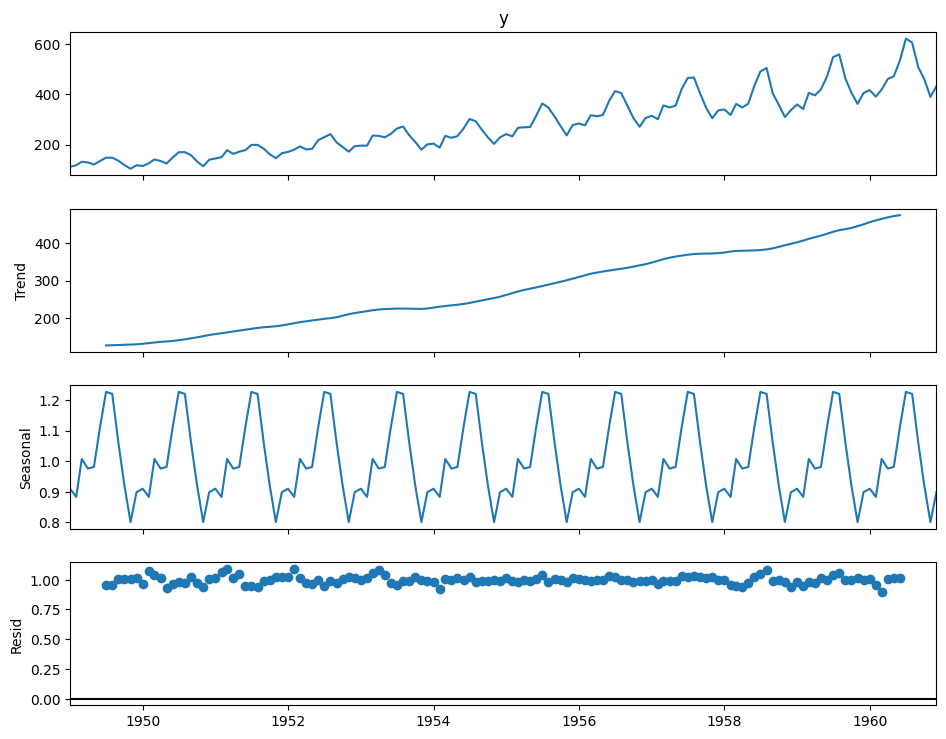

In [16]:
df = df.set_index('ds')
decomposition = sm.tsa.seasonal_decompose(df['y'], model='multiplicative', period=12)

# Plot the decomposed components
fig = decomposition.plot()
fig.set_size_inches(10, 8)
plt.show()

<Axes: xlabel='ds'>

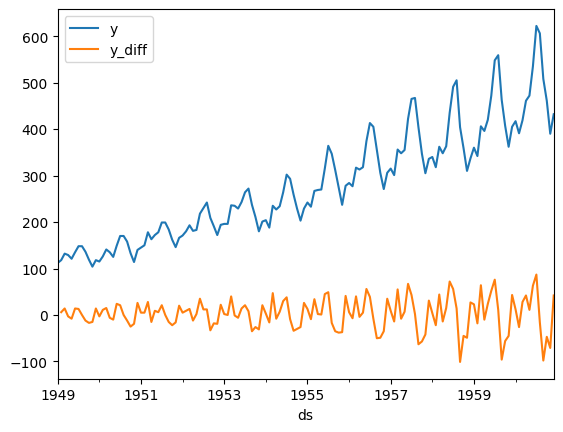

In [17]:
df_diff = df.copy()
df_diff['y_diff'] = df_diff['y'].diff()

df_diff.plot()



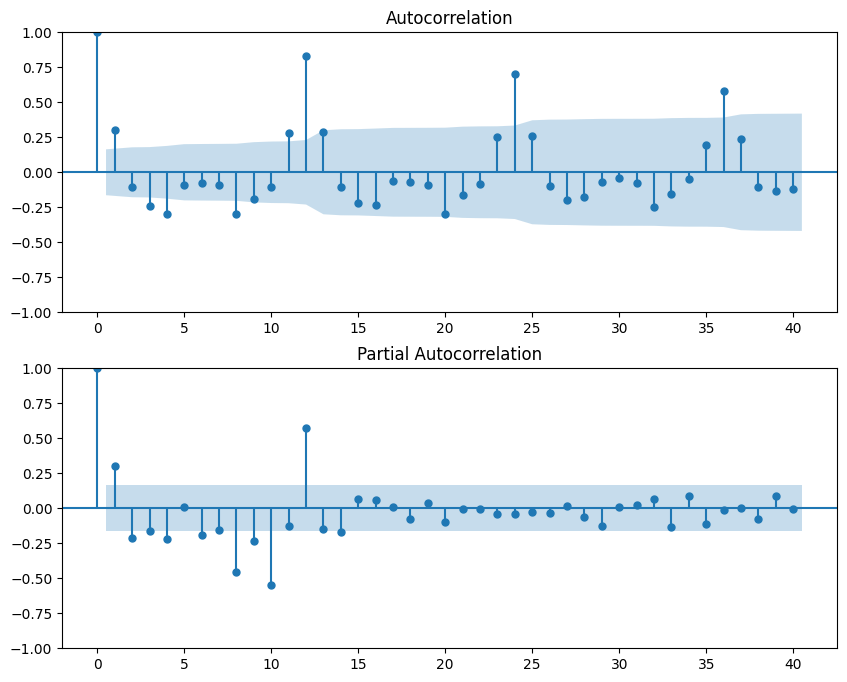

In [18]:
differenced_series = df['y'].diff().dropna()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

plot_acf(differenced_series, ax=ax1, lags=40)
plot_pacf(differenced_series, ax=ax2, lags=40)

plt.show()

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  143
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -694.061
Date:                Thu, 17 Jul 2025   AIC                           1396.122
Time:                        15:14:37   BIC                           1407.973
Sample:                    02-01-1949   HQIC                          1400.937
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.4507      3.441      0.712      0.476      -4.293       9.195
ar.L1         -0.4767      0.128     -3.735      0.000      -0.727      -0.227
ma.L1          0.8645      0.080     10.743      0.0

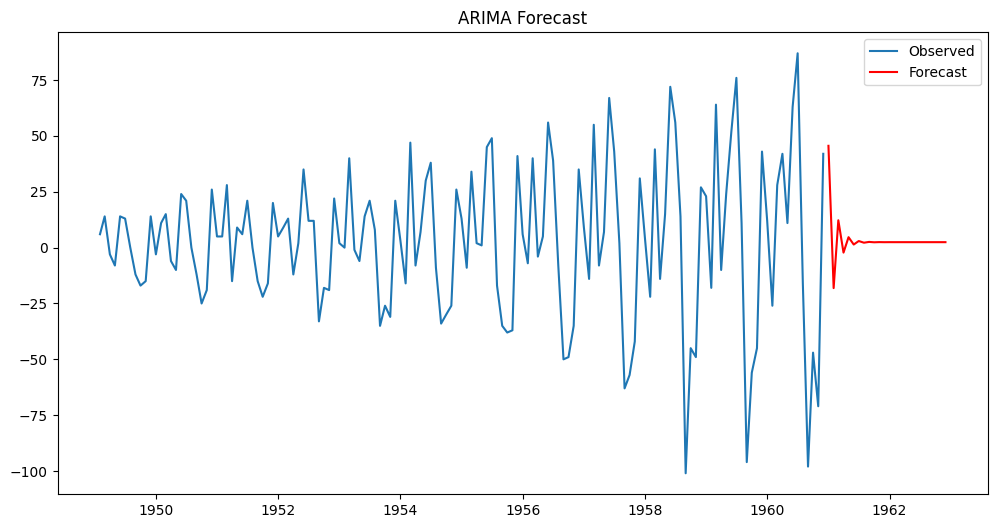

In [19]:
model = sm.tsa.ARIMA(differenced_series, order=(1, 0, 1))
results = model.fit()

# Print the model summary
print(results.summary())

# Generate forecasts
forecast_steps = 24
forecast = results.forecast(steps=forecast_steps)

# Plot the original series and the forecast
plt.figure(figsize=(12, 6))
plt.plot(differenced_series, label='Observed')
plt.plot(forecast, label='Forecast', color='red')
plt.title('ARIMA Forecast')
plt.legend()
plt.show()

## Modeling with `StatsForecast`

In [20]:
df = AirPassengersDF
sf = StatsForecast(
    models=[AutoARIMA(season_length = 12)],
    freq='MS',
)
sf.fit(df)
forecast_df = sf.predict(h=12, level=[90])
forecast_df.tail()

,unique_id,ds,AutoARIMA,AutoARIMA-lo-90,AutoARIMA-hi-90
7,1.0,1961-08-01,633.236374,590.009004,676.463744
8,1.0,1961-09-01,535.236400,489.558889,580.913911
9,1.0,1961-10-01,488.236392,440.233792,536.238991
10,1.0,1961-11-01,417.236394,367.016191,467.456597
11,1.0,1961-12-01,459.236394,406.892468,511.580319


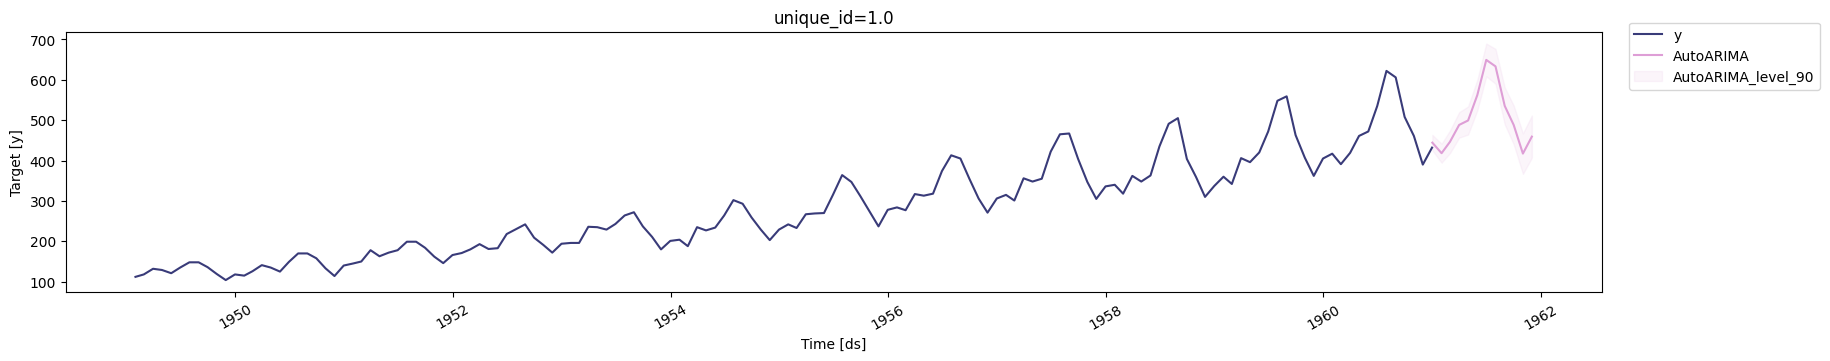

In [21]:
sf.plot(df, forecast_df, level=[90])

### Model Selection

In [22]:
# Create a list of models and instantiation parameters
models = [
    HoltWinters(),
    Croston(),
    SeasonalNaive(season_length=12),
    HistoricAverage(),
    DOT(season_length=12)
]

# Instantiate StatsForecast class as sf
sf = StatsForecast(
    models=models,
    freq='MS',
    n_jobs=-1,
    fallback_model=SeasonalNaive(season_length=7),
    verbose=True,
)

# Fit & Predict
forecasts_df = sf.forecast(df=df, h=48, level=[90])
forecasts_df.head()

Forecast:   0%|          | 0/1 [00:00<?, ?it/s]

,unique_id,ds,HoltWinters,HoltWinters-lo-90,HoltWinters-hi-90,CrostonClassic,CrostonClassic-lo-90,CrostonClassic-hi-90,SeasonalNaive,SeasonalNaive-lo-90,SeasonalNaive-hi-90,HistoricAverage,HistoricAverage-lo-90,HistoricAverage-hi-90,DynamicOptimizedTheta,DynamicOptimizedTheta-lo-90,DynamicOptimizedTheta-hi-90
0,1.0,1961-01-01,535.0,408.000589,661.999411,535.0,408.000589,661.999411,417.0,357.265915,476.734085,280.298611,82.287602,478.309621,442.927195,428.483001,461.145932
1,1.0,1961-02-01,622.0,495.000589,748.999411,622.0,495.000589,748.999411,391.0,331.265915,450.734085,280.298611,82.287602,478.309621,432.298401,413.104707,451.056264
2,1.0,1961-03-01,606.0,479.000589,732.999411,606.0,479.000589,732.999411,419.0,359.265915,478.734085,280.298611,82.287602,478.309621,495.482454,465.754303,519.855972
3,1.0,1961-04-01,508.0,381.000589,634.999411,508.0,381.000589,634.999411,461.0,401.265915,520.734085,280.298611,82.287602,478.309621,482.575341,454.981750,507.280996
4,1.0,1961-05-01,461.0,334.000589,587.999411,461.0,334.000589,587.999411,472.0,412.265915,531.734085,280.298611,82.287602,478.309621,487.865993,458.282904,517.063668


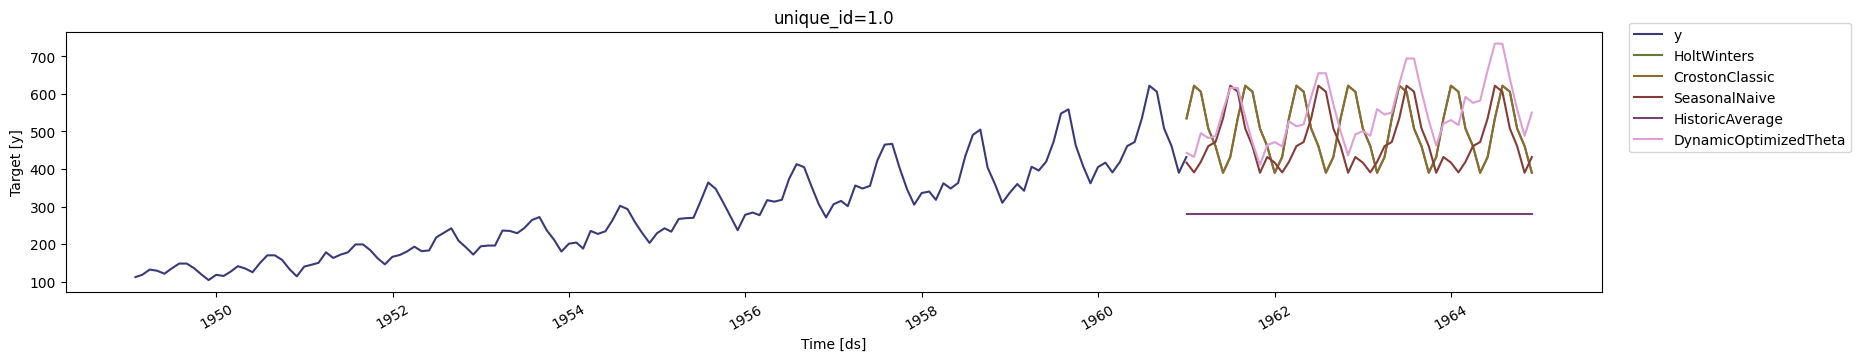

In [23]:
sf.plot(df,forecasts_df)

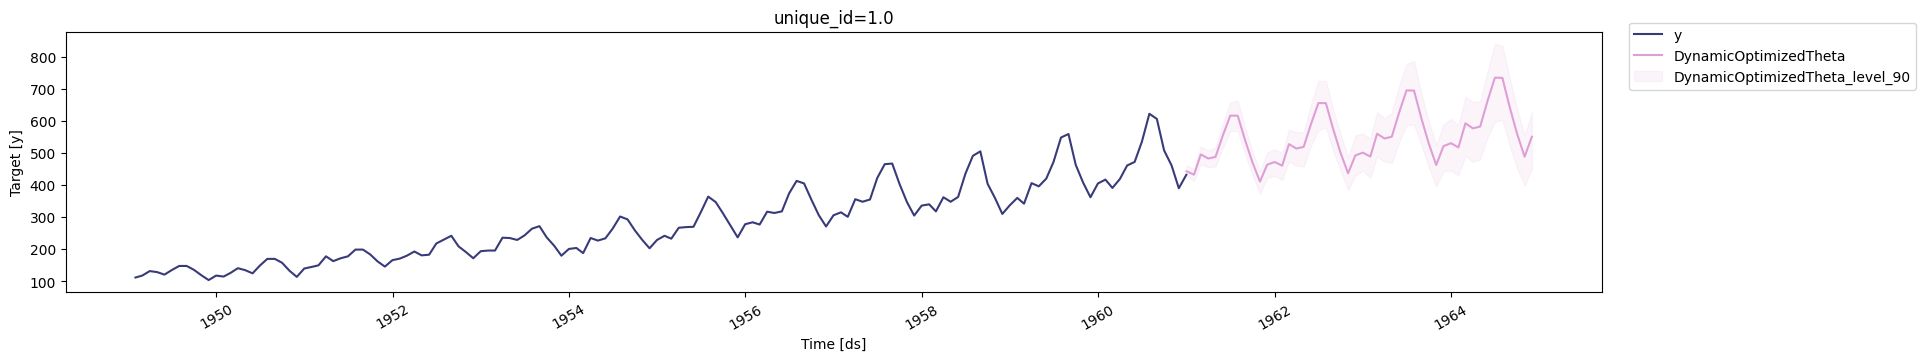

In [24]:
# Plot to unique_ids and some selected models
sf.plot(df, forecasts_df, models=["DynamicOptimizedTheta"], unique_ids=[1.0], level=[90])

### Cross Validation & Backtesting

In [25]:
cv_df = sf.cross_validation(
    df=df,
    h=12,
    step_size=12,
    n_windows=2
)
cv_df.head()

Cross Validation Time Series 1:   0%|          | 0/2 [00:00<?, ?it/s]

,unique_id,ds,cutoff,y,HoltWinters,CrostonClassic,SeasonalNaive,HistoricAverage,DynamicOptimizedTheta
0,1.0,1959-01-31,1958-12-31,360.0,435.0,373.359183,340.0,245.908333,343.838105
1,1.0,1959-02-28,1958-12-31,342.0,491.0,373.359183,318.0,245.908333,338.816742
2,1.0,1959-03-31,1958-12-31,406.0,505.0,373.359183,362.0,245.908333,390.327821
3,1.0,1959-04-30,1958-12-31,396.0,404.0,373.359183,348.0,245.908333,376.005771
4,1.0,1959-05-31,1958-12-31,420.0,359.0,373.359183,363.0,245.908333,378.212202


In [26]:
def evaluate_cv(df, metric):
    models = df.columns.drop(['unique_id', 'ds', 'y', 'cutoff']).tolist()
    evals = metric(df, models=models)
    evals['best_model'] = evals[models].idxmin(axis=1)
    return evals

evaluation_df = evaluate_cv(cv_df, mse)
display(evaluation_df.head())
evaluation_df['best_model'].value_counts()

,unique_id,HoltWinters,CrostonClassic,SeasonalNaive,HistoricAverage,DynamicOptimizedTheta,best_model
0,1.0,12727.333333,8358.86752,2498.666667,44472.461806,1274.200542,DynamicOptimizedTheta


,count
best_model,
DynamicOptimizedTheta,1


## End-to-End Time-Series Modeling Demo
Fitting a GARCH Model using `StatsForecast`

In [27]:
ticker = '^GSPC'
period1 = dt.datetime(2015, 1, 1)
period2 = dt.datetime(2023, 9, 22)
interval = '1d' # 1d, 1m

SP_500 = yf.download(ticker, start=period1, end=period2, interval=interval, progress=False)
SP_500 = SP_500.reset_index()

SP_500.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
0,2015-01-02,2058.199951,2072.360107,2046.040039,2058.899902,2708700000
1,2015-01-05,2020.579956,2054.439941,2017.339966,2054.439941,3799120000
2,2015-01-06,2002.609985,2030.250000,1992.439941,2022.150024,4460110000
3,2015-01-07,2025.900024,2029.609985,2005.550049,2005.550049,3805480000
4,2015-01-08,2062.139893,2064.080078,2030.609985,2030.609985,3934010000


,ds,y,unique_id
0,2015-01-02,2058.199951,1
1,2015-01-05,2020.579956,1
2,2015-01-06,2002.609985,1
3,2015-01-07,2025.900024,1
4,2015-01-08,2062.139893,1


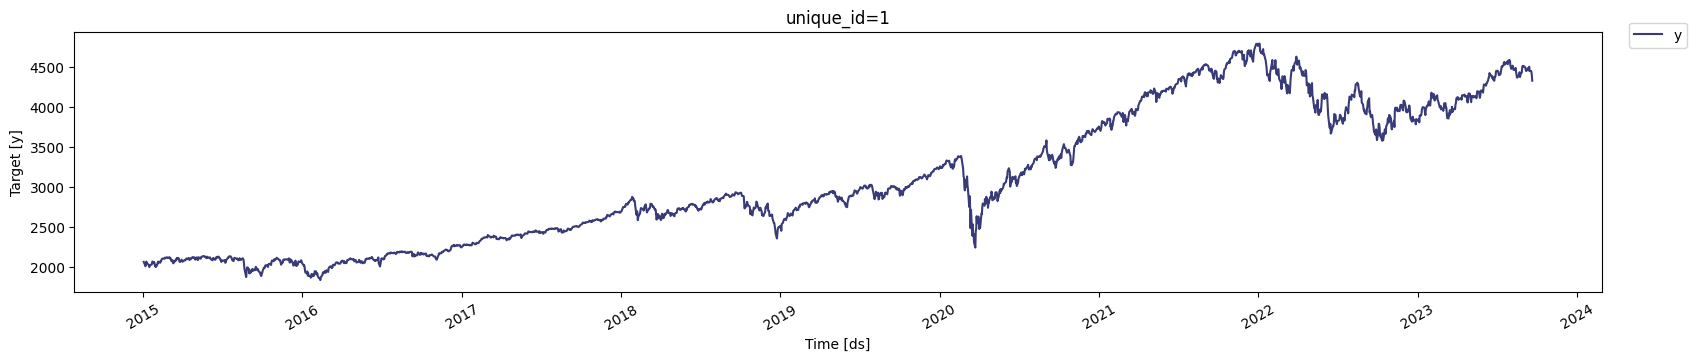

In [28]:
df=SP_500[["Date","Close"]]
df["unique_id"]="1"
df.columns=["ds", "y", "unique_id"]
display(df.head())
StatsForecast.plot(df)

### Augmented Dickey-Fuller Stationarity Test

In [29]:
def Augmented_Dickey_Fuller_Test_func(series , column_name):
    print (f'Dickey-Fuller test results for columns: {column_name}')
    dftest = adfuller(series, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','No Lags Used','Number of observations used'])
    for key,value in dftest[4].items():
       dfoutput['Critical Value (%s)'%key] = value
    print (dfoutput)
    if dftest[1] <= 0.05:
        print("Conclusion:====>")
        print("Reject the null hypothesis")
        print("The data is stationary")
    else:
        print("Conclusion:====>")
        print("The null hypothesis cannot be rejected")
        print("The data is not stationary")

In [30]:
Augmented_Dickey_Fuller_Test_func(df["y"],'S&P500')

Dickey-Fuller test results for columns: S&P500
Test Statistic                   -0.772384
p-value                           0.827100
No Lags Used                     10.000000
Number of observations used    2184.000000
Critical Value (1%)              -3.433348
Critical Value (5%)              -2.862864
Critical Value (10%)             -2.567475
dtype: float64
Conclusion:====>
The null hypothesis cannot be rejected
The data is not stationary


In [31]:
df['return'] = 100 * df["y"].pct_change()
df.dropna(inplace=True, how='any')
df['sq_return'] = df["return"].mul(df["return"])

display(df.head())

base = alt.Chart(df).mark_line().encode(
    x='ds',
    # y='return',
).properties(
    width=800,
    height=400,
    # title="SP500 Return Chart"
)
return_chart = base.encode(
    y='return'
).properties(
    title="SP500 Return Chart"
)
sq_return_chart = base.encode(
    y='sq_return'
).properties(
    title="SP500 Squared Return Chart"
)

(return_chart | sq_return_chart).properties(
    title="SP500 Return and Squared Return Chart"
)
# df.head()

,ds,y,unique_id,return,sq_return
1,2015-01-05,2020.579956,1,-1.827811,3.340891
2,2015-01-06,2002.609985,1,-0.889347,0.790938
3,2015-01-07,2025.900024,1,1.162984,1.352532
4,2015-01-08,2062.139893,1,1.788828,3.199906
5,2015-01-09,2044.810059,1,-0.840381,0.706240


alt.HConcatChart(...)

### Ljung-Box Autocorrelation Test

In [32]:
ljung_res = acorr_ljungbox(df["return"], lags= 40, boxpierce=True)

# ln_pvalue < 0.05 ? reject null hypotheses i.e. no autocorrelation
ljung_res.head()

,lb_stat,lb_pvalue,bp_stat,bp_pvalue
1,49.164612,2.353586e-12,49.097448,2.435569e-12
2,63.018660,2.068577e-14,62.926260,2.166388e-14
3,64.049336,8.011046e-14,63.954590,8.393659e-14
4,74.573167,2.452953e-15,74.449667,2.604989e-15
5,80.474832,6.675875e-16,80.332520,7.149674e-16


In [33]:
df=df[["ds","unique_id","return"]]
df.columns=["ds", "unique_id", "y"]
train = df[df.ds<='2023-05-31'] # Let's forecast the last 30 days
test = df[df.ds>'2023-05-31']
train.shape, test.shape

((2116, 3), (78, 3))

### Cross Validation & Model Selection

In [34]:
season_length = 7 # Dayly data
horizon = len(test) # number of predictions biasadj=True, include_drift=True,

models = [GARCH(1,1),
          GARCH(1,2),
          GARCH(2,2),
          GARCH(2,1),
          GARCH(3,1),
          GARCH(3,2),
          GARCH(3,3),
          GARCH(1,3),
          GARCH(2,3)]

sf = StatsForecast(
    models=models,
    freq='C', # custom business day frequency
)

crossvalidation_df = sf.cross_validation(df=train,
                                         h=horizon,
                                         step_size=6,
                                         n_windows=5)

crossvalidation_df

,unique_id,ds,cutoff,y,"GARCH(1,1)","GARCH(1,2)","GARCH(2,2)","GARCH(2,1)","GARCH(3,1)","GARCH(3,2)","GARCH(3,3)","GARCH(1,3)","GARCH(2,3)"
0,1,2023-01-04,2023-01-03,0.753897,1.678755,1.678412,1.680475,1.686649,1.719494,2.210902,1.702743,1.647114,1.637795
1,1,2023-01-05,2023-01-03,-1.164553,-0.728069,-0.745487,-0.730648,-0.722156,-0.738119,-0.824748,-0.755277,-0.740976,-0.744150
2,1,2023-01-06,2023-01-03,2.284078,-0.589733,-0.582982,-0.590078,-0.598076,-0.587109,-0.866347,-0.571160,-0.587807,-0.584692
3,1,2023-01-09,2023-01-03,-0.076763,-1.114531,-1.114033,-1.116427,-1.123330,-1.144224,-1.587027,-1.125483,-1.093560,-1.081367
4,1,2023-01-10,2023-01-03,0.697823,0.916124,0.927110,0.918457,0.915234,0.933551,1.191896,0.954699,0.918717,0.926879
...,...,...,...,...,...,...,...,...,...,...,...,...,...
385,1,2023-05-24,2023-02-07,-0.731860,0.809313,0.806137,0.812425,0.836433,0.849249,0.814983,0.798189,0.792139,0.782892
386,1,2023-05-25,2023-02-07,0.875758,0.287776,0.290758,0.289187,0.293660,0.298815,0.292301,0.290765,0.289186,0.290435
387,1,2023-05-26,2023-02-07,1.304909,-1.697814,-1.694747,-1.702537,-1.735631,-1.729903,-1.712997,-1.663399,-1.702160,-1.687723
388,1,2023-05-30,2023-02-07,0.001660,-0.326945,-0.337504,-0.329686,-0.330120,-0.334717,-0.327583,-0.330260,-0.338245,-0.332412


In [35]:
evals = evaluate(crossvalidation_df.drop(columns='cutoff'), metrics=[rmse], agg_fn='mean')
evals

,metric,"GARCH(1,1)","GARCH(1,2)","GARCH(2,2)","GARCH(2,1)","GARCH(3,1)","GARCH(3,2)","GARCH(3,3)","GARCH(1,3)","GARCH(2,3)"
0,rmse,1.383143,1.526258,1.481056,1.389969,1.453538,1.539906,1.392352,1.515796,1.389061


In [36]:
season_length = 7 # Dayly data
horizon = len(test) # number of predictions biasadj=True, include_drift=True,

models = [GARCH(1,1)]

sf = StatsForecast(models=models,
                   freq='C', # custom business day frequency
                  )
sf.fit(df=train)

StatsForecast(models=[GARCH(1,1)], freq='C')

result=sf.fitted_[0,0].model_
display(result)

residual=pd.DataFrame(result.get("actual_residuals"), columns=["residual Model"])
display(residual)

{'p': 1,
 'q': 1,
 'coeff': array([0.03745049, 0.18399111, 0.7890637 ]),
 'message': 'Optimization terminated successfully',
 'y_vals': array([-0.61086242]),
 'sigma2_vals': array([0.76298402]),
 'fitted': array([        nan,  2.14638896, -0.76426268, ..., -0.19747638,
         0.76993462,  0.13183178]),
 'actual_residuals': array([        nan, -3.03573613,  1.92724695, ...,  1.50238505,
        -0.7682743 , -0.7426942 ])}

,residual Model
0,NaN
1,-3.035736
2,1.927247
3,2.439535
4,0.608668
...,...
2111,-0.451834
2112,0.560200
2113,1.502385
2114,-0.768274


,unique_id,ds,"GARCH(1,1)","GARCH(1,1)-lo-95","GARCH(1,1)-hi-95"
0,1,2023-06-01,1.366914,-0.021035,2.754863
1,1,2023-06-02,-0.593121,-2.435497,1.249254
2,1,2023-06-05,-0.485200,-2.139216,1.168815
3,1,2023-06-06,-0.927145,-2.390566,0.536276
4,1,2023-06-07,0.766640,-0.771479,2.304759


,unique_id,ds,y,"GARCH(1,1)","GARCH(1,1)-lo-95","GARCH(1,1)-hi-95"
0,1,2015-01-05,-1.827811,NaN,NaN,NaN
1,1,2015-01-06,-0.889347,2.146389,-0.972874,5.265652
2,1,2015-01-07,1.162984,-0.764263,-3.883526,2.355000
3,1,2015-01-08,1.788828,-0.650707,-3.769970,2.468556
4,1,2015-01-09,-0.840381,-1.449049,-4.568312,1.670214


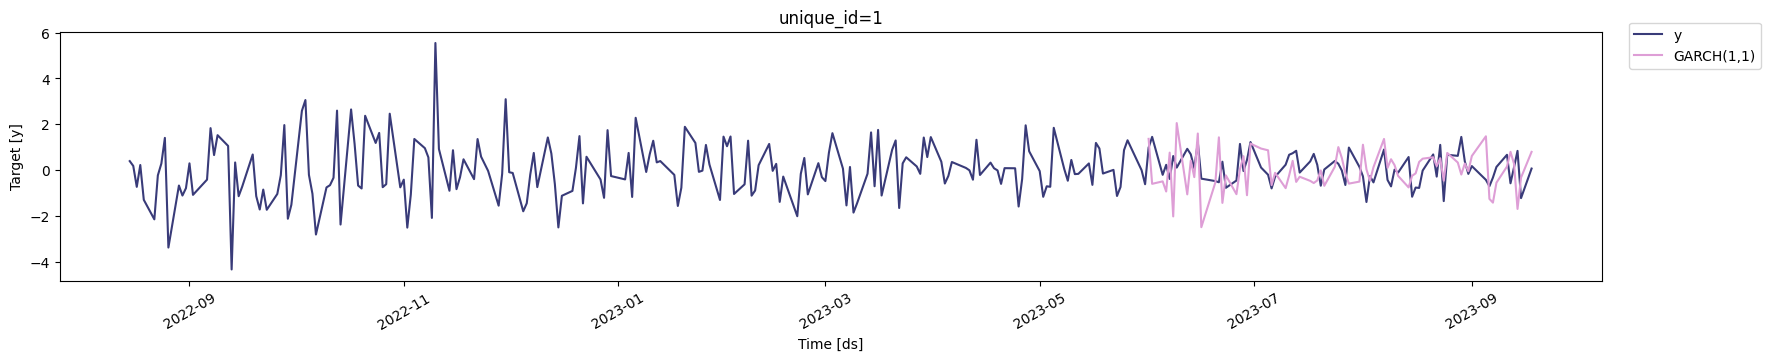

In [37]:
Y_hat = sf.forecast(df=train, h=horizon, fitted=True, level=[95])
display(Y_hat.head())
values=sf.forecast_fitted_values()
display(values.head())
sf.plot(train, Y_hat.merge(test), max_insample_length=200)

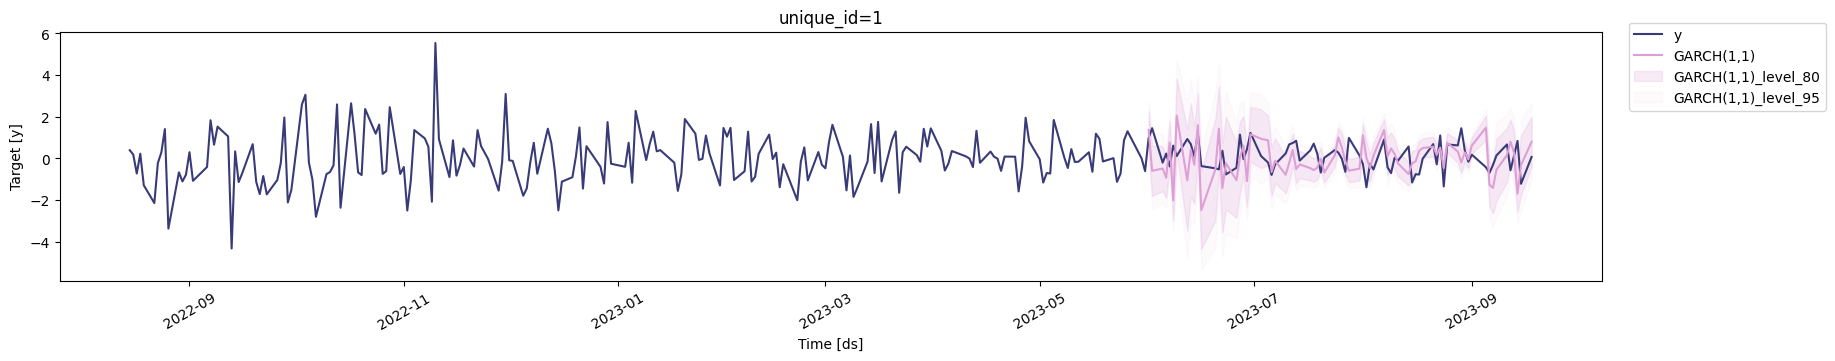

In [38]:
forecast_df = sf.predict(h=horizon, level=[80,95])
sf.plot(train, test.merge(forecast_df), level=[80, 95], max_insample_length=200)

### Model Evaluation

In [39]:
evaluate(
    test.merge(Y_hat),
    metrics=[mae, mape, partial(mase, seasonality=season_length), rmse, smape],
    train_df=train,
)

,unique_id,metric,"GARCH(1,1)"
0,1,mae,0.843296
1,1,mape,3.703305
2,1,mase,0.794905
3,1,rmse,1.048076
4,1,smape,0.709150


## Next Steps

- Try time series modeling on your project dataset.
- Read up on different models and their hyperparameters.
- Understand different evaluation metrics used in rating model performance.

## References

- [StatsForecast - Quick Start](https://nixtlaverse.nixtla.io/statsforecast/docs/getting-started/getting_started_short.html)
- [Pandas - Time Series Frequency/Offset Alias](https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#offset-aliases)
- [Polars - Time Series Frequency/Offset Alias](https://docs.pola.rs/api/python/stable/reference/series/api/polars.Series.dt.offset_by.html#polars.Series.dt.offset_by)
- [Cross Validation using `StatsForecast`](https://nixtlaverse.nixtla.io/statsforecast/docs/getting-started/getting_started_complete.html#evaluate-the-model%E2%80%99s-performance)
- [AutoARIMA Model](https://nixtlaverse.nixtla.io/statsforecast/docs/models/autoarima.html)
- [HoltWinters Model](https://nixtlaverse.nixtla.io/statsforecast/docs/models/holtwinters.html)
- [CrostonClassic Model](https://nixtlaverse.nixtla.io/statsforecast/docs/models/crostonclassic.html)
- [SeasonalNaive Model](https://nixtlaverse.nixtla.io/statsforecast/src/core/models.html#seasonalnaive-2)
- [Dynamic Optimized Theta Model](https://nixtlaverse.nixtla.io/statsforecast/docs/models/dynamicoptimizedtheta.html)